# P03: Dreamer 에이전트 학습

월드모델과 잠재 Actor-Critic 정책을 갖춘 컴팩트한 Dreamer 에이전트를 학습시킵니다. 이 노트북은 튜토리얼 규모의 데모입니다. 목표는 어려운 제어 벤치마크를 푸는 것이 아니라 Dreamer 학습 루프, 체크포인트 연결, 지표 진단을 보여주는 것입니다. 외부 gym 의존성은 없습니다. `SyntheticEnv`가 단순한 보상 신호와 함께 64x64 RGB 프레임을 생성합니다.

**선행 조건**: P01(`vae_encoder.pt`)과 P02(`rssm.pt`)가 있으면 사용합니다. 없으면 해당 부분이 무작위 초기화로 대체되어 노트북은 여전히 실행되지만, 학습된 에이전트는 사전학습된 체크포인트가 있어야만 의미가 있습니다. 이 노트북은 전체 에이전트를 `dreamer.pt`로 저장해 P05에 전달합니다.

여기서는 노이즈가 섞인 보상 추이도 괜찮습니다. 튜토리얼의 목표는 벤치마크 점수가 아니라 동작하는 월드모델 + 정책 파이프라인이기 때문입니다.

> Notebook 원본: [p03_dreamer_agent.ipynb](https://github.com/datawhalechina/learn-world-model/blob/main/docs/ko/projects/p03_dreamer_agent.ipynb)

In [1]:
%%bash
# Install dependencies for a fresh environment.
if command -v rocm-smi >/dev/null || [ -d /opt/rocm ]; then
  pip install torch torchvision --index-url https://download.pytorch.org/whl/rocm7.2
  pip install matplotlib numpy
else
  pip install torch torchvision matplotlib numpy
fi


## 1. 준비

공유 환경, 모델 차원, 학습 일정을 정의합니다. 이 노트북은 앞선 강의들의 네 요소를 [완전한 Dreamer 파이프라인](../lectures/lecture-02-encode-and-dynamics/03-dynamics-dreamer-series#the-encoders-role-as-a-bridge-in-dreamer)으로 조립합니다. 인코딩, RSSM으로 미래 예측, 액터와 크리틱으로 상상된 궤적 평가, 그리고 실제 환경에서의 실행입니다. 짚어두어야 할 의도적인 단순화가 하나 있습니다(뒤쪽 코드에서 갑작스럽지 않도록 여기서 미리 알려둡니다). 이 노트북의 액터는 [강의의 잠재 Actor-Critic](../lectures/lecture-03-architecture-patterns/05-planning-cem-ac#mechanism-2-actor-critic-in-latent-space-dreamers-approach)이 설명하는 것처럼 상상된 보상을 통한 역전파로 학습되지 않고, 손으로 짠 전문가 정책을 모방하는 방식(4절의 `supervised_policy_update`)으로 학습됩니다. 여기서 상상된 반환값으로 학습되는 것은 크리틱뿐입니다. 이 덕분에 튜토리얼 규모의 에이전트가 몇 분 안에 안정적으로 학습됩니다. 3절은 여전히 실제 Dreamer 액터 업데이트가 사용할 완전한 미분 가능 상상 메커니즘 전체를 구현합니다.

In [ ]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from pathlib import Path
try:
    from IPython import get_ipython
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass
import matplotlib.pyplot as plt
from collections import deque

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

try:
    import torch_xla.core.xla_model as xm
    _XLA_AVAILABLE = True
except Exception:
    xm = None
    _XLA_AVAILABLE = False


def _resolve_device():
    if _XLA_AVAILABLE:
        return xm.xla_device()
    if torch.cuda.is_available():
        return torch.device('cuda')
    return torch.device('cpu')


DEVICE = _resolve_device()
USE_TPU = DEVICE.type == 'xla'
USE_CUDA = DEVICE.type == 'cuda'
LOAD_DEVICE = torch.device('cpu') if USE_TPU else DEVICE


def optimizer_step(optimizer, scaler=None):
    if USE_TPU:
        xm.optimizer_step(optimizer)
    elif scaler is not None:
        scaler.step(optimizer)
        scaler.update()
    else:
        optimizer.step()

print(f'Using device: {DEVICE}')
if USE_CUDA:
    print(f'CUDA available: {torch.cuda.is_available()}')

Using device: cuda
CUDA available: True


### 1.1 하이퍼파라미터

전체 루프가 빠르게 실행되도록 설정값을 작게 유지합니다. 이 중 세 개는 강의 개념과 직접 대응됩니다. `IMAGINE_H = 10`은 [CEM-MPC와 잠재 Actor-Critic](../lectures/lecture-03-architecture-patterns/05-planning-cem-ac)에서 나온 상상 지평선 $H$로, 반환값을 계산하기 전에 월드모델 안에서 앞으로 굴리는 스텝 수입니다. `LAMBDA_RETURN = 0.95`는 강의의 $\lambda$-반환값에서 나온 $\lambda$입니다. 1에 가까울수록 실제(상상된) 롤아웃을 더 신뢰하고, 0에 가까울수록 크리틱 자신의 가치 추정을 더 신뢰합니다. `GAMMA = 0.99`는 같은 페이지의 CEM 의사코드에서 나온 할인율 $\gamma$로, 미래 상상된 보상이 얼마나 빨리 할인되는지를 제어합니다.

In [3]:
# Model dimensions
IMG_SIZE    = 64
LATENT_DIM  = 32      # VAE / stochastic latent z
HIDDEN_DIM  = 128     # RSSM deterministic h
ACTION_DIM  = 2       # binary action space
AC_HIDDEN   = 128     # Actor / Critic hidden size

# Training schedule
EPISODE_LEN   = 20    # steps per synthetic episode
N_ITERATIONS  = 30    # outer training iterations
BATCH_SIZE    = 4     # number of trajectories per world-model update
IMAGINE_H     = 10    # imagination horizon
LAMBDA_RETURN = 0.95  # TD(lambda)
GAMMA         = 0.99  # discount factor

# Learning rates
LR_WM   = 3e-4
LR_AC   = 3e-4

# Checkpoint paths (from earlier projects)
ENCODER_PATH = 'vae_encoder.pt'
RSSM_PATH    = 'rssm.pt'
SAVE_PATH    = 'dreamer.pt'

### 1.2 VAE 인코더

P01과 같은 인코더 구조를 사용하되 한 가지가 추가됩니다. 여기서 `VAEDecoder.forward`는 P01과 P02처럼 `z`만이 아니라 `z`와 `h`를 함께 입력받습니다(`torch.cat([z, h], dim=-1)`). 이는 [RSSM 절](../lectures/lecture-02-encode-and-dynamics/02-dynamics#why-separate-them)에 나온 강의의 관측 모델 $o_t \sim p(o_t \mid h_t, z_t)$와 일치합니다. 재구성은 결정론적 기억 `h_t`와 확률적 지각 `z_t` 모두에 조건화되며, 더 단순한 P01/P02 디코더처럼 `z_t`에만 조건화되지 않습니다.

In [4]:
class VAEEncoder(nn.Module):
    """Encode 64x64 RGB frames into latent mean and logvar."""
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1),   # 32x32
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),  # 16x16
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1), # 8x8
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, stride=2, padding=1),# 4x4
            nn.ReLU(),
        )
        self.fc_mu     = nn.Linear(256 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(256 * 4 * 4, latent_dim)

    def forward(self, x):
        """x: (B, 3, 64, 64) -> mu, logvar each (B, latent_dim)"""
        h = self.conv(x).view(x.size(0), -1)
        return self.fc_mu(h), self.fc_logvar(h)

    def encode(self, x):
        mu, logvar = self.forward(x)
        std = (0.5 * logvar).exp()
        eps = torch.randn_like(std)
        return mu + eps * std, mu, logvar


class VAEDecoder(nn.Module):
    """Decoder: latent_dim -> 64x64 RGB reconstruction."""
    def __init__(self, latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.fc = nn.Linear(latent_dim + hidden_dim, 256 * 4 * 4)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, z, h):
        """z: (B, latent_dim), h: (B, hidden_dim) -> (B, 3, 64, 64)"""
        x = self.fc(torch.cat([z, h], dim=-1))
        x = x.view(x.size(0), 256, 4, 4)
        return self.deconv(x)

### 1.3 RSSM

P02의 잠재 동역학 인터페이스를 재사용하되, P02의 단일 `forward` 루프 대신 세 개의 별도 메서드(`prior`, `posterior`, `step`)로 재구성해, 이 노트북이 각 부분을 독립적으로 호출할 수 있게 합니다. `step`은 `h`를 진행시키고, `prior`/`posterior`는 `z`를 샘플링합니다. 이 분리 덕분에 아래 `imagined_rollout`이 가능해집니다. 상상은 (관측 없이) `prior`만 필요하지만 학습은 (관측을 갖춘) `posterior`가 필요하기 때문이며, 이는 정확히 [강의의 사전분포 대 사후분포 설명 상자](../lectures/lecture-02-encode-and-dynamics/02-dynamics#rssm-separating-deterministic-and-stochastic-components)가 설명하는 분리입니다.

짚고 넘어갈 구현 세부사항이 하나 있습니다. `prior`와 `posterior`는 P02의 `std = (0.5 * logvar).exp()` 대신 `std = F.softplus(logvar) + 0.1`을 사용합니다. 둘 다 제약 없는 네트워크 출력에서 양수인 표준편차를 보장하는 유효한 방법입니다. `softplus(x) + 0.1`은 추가로 표준편차의 최솟값을 0.1로 강제하는데, 이는 거의 결정론적인 사후분포가 KL 항을 정확히 0으로 몰아붙이는 것을 막아줍니다. [L04의 Dreamer 진단](../lectures/lecture-04-evaluation-by-model/01-model-metrics-dreamer#imagined-trajectory-entropy)에서 다룬 사후붕괴 실패 모드에 대한 직접적인 방어책입니다.

In [5]:
class RSSM(nn.Module):
    """P02-compatible RSSM with a P03-friendly action interface."""
    def __init__(self, latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM, action_dim=ACTION_DIM):
        super().__init__()
        self.latent_dim = latent_dim
        self.hidden_dim = hidden_dim
        self.action_dim = action_dim

        # P02 checkpoint expects a scalar action feature.
        self.gru = nn.GRUCell(latent_dim + 1, hidden_dim)

        # Prior: p(z_t | h_t)
        self.prior_net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, 2 * latent_dim),
        )

        # Posterior: q(z_t | h_t, e_t)
        self.post_net = nn.Sequential(
            nn.Linear(hidden_dim + latent_dim, hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, 2 * latent_dim),
        )
        self.recon = nn.Linear(latent_dim, latent_dim)

    def _action_feature(self, action):
        """Convert scalar or one-hot actions to the P02 scalar action input."""
        if action.dim() == 0:
            action = action.view(1, 1)
        elif action.dim() == 1:
            action = action.unsqueeze(-1)
        if action.shape[-1] > 1:
            # Binary actions: keep the mass on action 1 so soft imagined
            # actions remain differentiable during actor training.
            action = action[..., 1:2]
        return action.float()

    def initial_state(self, batch_size):
        h = torch.zeros(batch_size, self.hidden_dim, device=DEVICE)
        z = torch.zeros(batch_size, self.latent_dim, device=DEVICE)
        return h, z

    def prior(self, h):
        out = self.prior_net(h)
        mu, logvar = out.chunk(2, dim=-1)
        std = F.softplus(logvar) + 0.1
        z = mu + std * torch.randn_like(std)
        return z, mu, std

    def posterior(self, h, enc_z):
        out = self.post_net(torch.cat([h, enc_z], dim=-1))
        mu, logvar = out.chunk(2, dim=-1)
        std = F.softplus(logvar) + 0.1
        z = mu + std * torch.randn_like(std)
        return z, mu, std

    def step(self, h, z, action_onehot):
        """Advance deterministic state. Returns new h."""
        action_feat = self._action_feature(action_onehot)
        inp = torch.cat([z, action_feat], dim=-1)
        h_new = self.gru(inp, h)
        return h_new

### 1.4 액터와 크리틱

픽셀이 아니라 `(h, z)` 쌍을 다루며 전적으로 잠재 공간에서 학습됩니다. 실제 관측이 필요 없다는 같은 속성 덕분에 순수 상상 학습이 가능해집니다. `Actor.forward`는 선택적으로 `bar_pos` 특징도 받습니다. 이는 다음에 정의할 합성 막대 균형 환경에 특화된 지름길이지 일반적인 Dreamer 아키텍처의 일부가 아니며, 생략되면(아래 `imagined_rollout`에서처럼 계산할 실제 관측이 없을 때처럼) 기본값 0으로 처리됩니다. `RewardModel`은 액터와 크리틱과 함께 정의됩니다. Dreamer는 상상된 롤아웃 *안에서* 보상을 예측해야 하는데, 상상된 상태는 보상 신호를 물어볼 실제 환경이 없기 때문입니다. 그래서 학습된 보상 모델은 동역학 모델 자체만큼이나 필수적인 구성 요소입니다.

In [6]:
class Actor(nn.Module):
    """Map latent state (h, z) and a lightweight observation feature to action logits."""
    def __init__(self, latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM, action_dim=ACTION_DIM, ac_hidden=AC_HIDDEN, obs_feat_dim=1):
        super().__init__()
        inp = hidden_dim + latent_dim + obs_feat_dim
        self.net = nn.Sequential(
            nn.Linear(inp, ac_hidden),
            nn.ELU(),
            nn.Linear(ac_hidden, ac_hidden),
            nn.ELU(),
            nn.Linear(ac_hidden, action_dim),
        )

    def forward(self, h, z, bar_pos=None):
        if bar_pos is None:
            bar_pos = torch.zeros(h.shape[0], 1, device=h.device)
        logits = self.net(torch.cat([h, z, bar_pos], dim=-1))
        return logits

    def sample(self, h, z, bar_pos=None):
        logits = self.forward(h, z, bar_pos=bar_pos)
        dist = torch.distributions.Categorical(logits=logits)
        action = dist.sample()
        return action, dist


class Critic(nn.Module):
    """Maps latent state (h, z) to scalar value estimate."""
    def __init__(self, latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM, ac_hidden=AC_HIDDEN):
        super().__init__()
        inp = hidden_dim + latent_dim
        self.net = nn.Sequential(
            nn.Linear(inp, ac_hidden),
            nn.ELU(),
            nn.Linear(ac_hidden, ac_hidden),
            nn.ELU(),
            nn.Linear(ac_hidden, 1),
        )

    def forward(self, h, z):
        return self.net(torch.cat([h, z], dim=-1)).squeeze(-1)


class RewardModel(nn.Module):
    """Predict immediate reward from latent state and action."""
    def __init__(self, latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM, action_dim=ACTION_DIM, ac_hidden=AC_HIDDEN):
        super().__init__()
        inp = hidden_dim + latent_dim + action_dim
        self.net = nn.Sequential(
            nn.Linear(inp, ac_hidden),
            nn.ELU(),
            nn.Linear(ac_hidden, ac_hidden),
            nn.ELU(),
            nn.Linear(ac_hidden, 1),
        )

    def forward(self, h, z, a):
        return self.net(torch.cat([h, z, a], dim=-1)).squeeze(-1)

### 1.5 합성 환경

`SyntheticEnv`는 이 노트북을 위해 특별히 만든 최소한의 제어 과제로, 강의에서 소개된 것은 아닙니다. 빨간 막대의 수평 위치 `pos`가 이진 동작에 따라 고정된 스텝만큼 왼쪽이나 오른쪽으로 움직이고, 동작이 막대를 중앙에 더 가깝게 만들면(`abs(pos) < prev_abs`) 보상은 `+1`, 아니면 `-1`입니다. 이 덕분에 "막대를 중앙 근처에 유지하기"가 최적 정책이 되며, CPU에서 몇 분의 학습만으로도 동작하는 Dreamer 루프를 보여줄 수 있을 만큼 단순합니다. 그러면서도 에이전트가 (인코더를 통해) 픽셀에서 위치를 읽고 (RSSM과 액터를 통해) 여러 스텝에 걸친 신호에 따라 행동해야 하므로, 한 줄짜리 휴리스틱으로 과제를 풀 수는 없습니다.

In [7]:
class SyntheticEnv:
    """Simple synthetic control environment with image observations."""
    def __init__(self, episode_len=EPISODE_LEN, img_size=IMG_SIZE, seed=None):
        self.episode_len = episode_len
        self.img_size    = img_size
        self.rng         = np.random.default_rng(seed)
        self.pos         = 0.0
        self.step_count  = 0

    def _render(self):
        img = np.zeros((self.img_size, self.img_size, 3), dtype=np.float32)
        bar_x = int((self.pos + 1.0) / 2.0 * (self.img_size - 1))
        bar_x = np.clip(bar_x, 0, self.img_size - 1)
        img[:, max(0, bar_x - 2): bar_x + 3, 0] = 1.0  # red channel
        # Add mild background noise to make the encoder non-trivial
        img += self.rng.uniform(0, 0.05, img.shape).astype(np.float32)
        return np.clip(img, 0, 1)

    def reset(self):
        self.pos        = float(self.rng.uniform(-0.8, 0.8))
        self.step_count = 0
        return self._render()

    def step(self, action):
        """action: int (0 or 1). Returns (obs, reward, done)."""
        prev_abs = abs(self.pos)
        delta    = 0.1 if action == 1 else -0.1
        self.pos = float(np.clip(self.pos + delta, -1.0, 1.0))
        reward   = 1.0 if abs(self.pos) < prev_abs else -1.0
        self.step_count += 1
        done = self.step_count >= self.episode_len
        return self._render(), reward, done


# Quick sanity check
env = SyntheticEnv(seed=0)
obs = env.reset()
print(f'Observation shape: {obs.shape}, dtype: {obs.dtype}, range: [{obs.min():.2f}, {obs.max():.2f}]')
obs2, r, done = env.step(1)
print(f'After step: reward={r}, done={done}')

Observation shape: (64, 64, 3), dtype: float32, range: [0.00, 1.00]
After step: reward=-1.0, done=False


### 1.6 모델 불러오기 또는 초기화

있으면 `vae_encoder.pt`(P01)와 `rssm.pt`(P02)를 불러옵니다. `_load_encoder_decoder_from_vae_checkpoint`의 주석을 눈여겨보세요. P01 체크포인트에서 재사용되는 것은 *인코더* 가중치뿐입니다. P03의 디코더는 의도적으로 다시 초기화되어 처음부터 재학습됩니다. P03의 디코더 구조가 P01과 다르기 때문인데(위 1.2절에서 언급했듯 `h`에도 추가로 조건화됩니다), 그래서 재사용하더라도 P01 디코더 가중치는 형태상 맞지 않습니다. 둘 중 하나라도 체크포인트가 없으면 해당 모듈은 무작위 초기화로 대체되어 노트북은 여전히 실행되지만, 결과 에이전트는 P01/P02에서 학습된 표현 위에 쌓이지 못하므로 더 약한 데모가 됩니다.

In [ ]:
def obs_to_tensor(obs):
    """Convert HWC numpy float32 -> (1, 3, H, W) tensor."""
    t = torch.from_numpy(obs).permute(2, 0, 1).unsqueeze(0)
    return t.to(DEVICE)


encoder = VAEEncoder(latent_dim=LATENT_DIM).to(DEVICE)
decoder = VAEDecoder(latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM).to(DEVICE)
rssm    = RSSM(latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM, action_dim=ACTION_DIM).to(DEVICE)
actor   = Actor(latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM, action_dim=ACTION_DIM, ac_hidden=AC_HIDDEN).to(DEVICE)
critic  = Critic(latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM, ac_hidden=AC_HIDDEN).to(DEVICE)
reward_model = RewardModel(latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM, action_dim=ACTION_DIM, ac_hidden=AC_HIDDEN).to(DEVICE)

# Attempt to load weights from earlier projects.
def _load_encoder_decoder_from_vae_checkpoint(path):
    ckpt = torch.load(path, map_location=DEVICE)
    state = ckpt.get('model_state_dict', ckpt) if isinstance(ckpt, dict) else ckpt

    if isinstance(ckpt, dict) and 'encoder' in ckpt:
        enc_state = {k.replace('fc_log_var', 'fc_logvar'): v for k, v in ckpt['encoder'].items()}
        encoder.load_state_dict(enc_state, strict=True)
        return 'encoder only (decoder is intentionally re-initialized in P03)'

    enc_state = {}
    dec_state = {}
    for key, value in state.items():
        if key.startswith('encoder.'):
            enc_key = key[len('encoder.'):].replace('fc_log_var', 'fc_logvar')
            enc_state[enc_key] = value
        elif key.startswith('decoder.'):
            dec_state[key[len('decoder.'):]] = value

    if not enc_state:
        raise KeyError(f'Unrecognized VAE checkpoint format: {list(ckpt.keys())[:10] if isinstance(ckpt, dict) else type(ckpt)}')

    encoder.load_state_dict(enc_state, strict=True)
    return 'encoder only from model_state_dict (decoder is intentionally re-initialized in P03)'

vae_ckpt_candidates = [Path(ENCODER_PATH), Path('notebooks') / ENCODER_PATH]
vae_ckpt_path = next((p for p in vae_ckpt_candidates if p.exists()), None)
if vae_ckpt_path is not None:
    try:
        vae_ckpt_format = _load_encoder_decoder_from_vae_checkpoint(vae_ckpt_path)
        print(f'Loaded encoder/decoder weights from {vae_ckpt_path} ({vae_ckpt_format})')
    except Exception as e:
        print(f'Could not load encoder/decoder from {vae_ckpt_path} ({e}), using random init')
else:
    print('vae_encoder.pt not found; using random encoder init')

rssm_path = next((p for p in [Path(RSSM_PATH), Path('notebooks') / RSSM_PATH] if p.exists()), None)
if rssm_path is not None:
    try:
        state = torch.load(rssm_path, map_location=DEVICE)
        if isinstance(state, dict) and 'rssm_state_dict' in state:
            sd = state['rssm_state_dict']
            rssm.load_state_dict(sd, strict=True)
            print(
                f"Loaded RSSM weights from {rssm_path} "
                f"(hidden_dim={state.get('hidden_dim', HIDDEN_DIM)}, latent_dim={state.get('latent_dim', LATENT_DIM)}, action_dim={state.get('action_dim', 1)})"
            )
        elif isinstance(state, dict) and 'rssm' in state:
            rssm.load_state_dict(state['rssm'], strict=False)
            print(f'Loaded RSSM weights from {rssm_path} (legacy rssm key)')
        else:
            rssm.load_state_dict(state, strict=False)
            print(f'Loaded RSSM weights from {rssm_path} (raw state_dict)')
    except Exception as e:
        print(f'Could not load RSSM ({e}), using random init')
else:
    print('rssm.pt not found; using random RSSM init')

print('\nModel parameter counts:')
for name, m in [('encoder', encoder), ('decoder', decoder), ('rssm', rssm), ('actor', actor), ('critic', critic), ('reward_model', reward_model)]:
    n = sum(p.numel() for p in m.parameters())
    print(f'  {name}: {n:,}')

Loaded encoder/decoder weights from vae_encoder.pt (encoder only (decoder is intentionally re-initialized in P03))
Loaded RSSM weights from rssm.pt (hidden_dim=128, latent_dim=32, action_dim=1)

Model parameter counts:
  encoder: 952,352
  decoder: 1,349,347
  rssm: 117,280
  actor: 37,506
  critic: 37,249
  reward_model: 37,505


### 1.7 리플레이 버퍼와 옵티마이저

`replay_buffer`는 수집된 궤적들의 고정 크기 FIFO 큐(`deque(maxlen=200)`)로, 이후의 월드모델 업데이트와 지도학습 정책 업데이트 모두를 위한 학습 데이터 소스입니다. `opt_wm`은 `encoder + decoder + rssm + reward_model`을 하나의 파라미터 그룹으로 함께 최적화하는 반면, `opt_actor`와 `opt_critic`은 별도의 옵티마이저라는 점에 유의하세요. 이 분리가 중요한 이유는, 1절에서 언급했듯 액터와 크리틱이 서로 다른 메커니즘(모방 대 상상된 반환값)으로 학습되므로 그래디언트 업데이트를 공유해서는 안 되기 때문입니다.

In [9]:
# Replay buffer stores trajectory dictionaries.
replay_buffer = deque(maxlen=200)

# World model optimizer covers encoder + decoder + RSSM
wm_params = list(encoder.parameters()) + list(decoder.parameters()) + list(rssm.parameters()) + list(reward_model.parameters())
opt_wm    = optim.Adam(wm_params, lr=LR_WM)

opt_actor  = optim.Adam(actor.parameters(),  lr=LR_AC)
opt_critic = optim.Adam(critic.parameters(), lr=LR_AC)

print('Optimizers initialized.')

Optimizers initialized.


## 2. 월드모델 업데이트

`world_model_update`는 [P02](../projects/p02_rssm_dynamics)의 월드모델 학습 루프를 이 노트북에 맞게 확장한 버전으로, 보상 예측도 함께 수행합니다. 궤적의 각 스텝마다 현재 관측을 인코딩하고(`encoder.encode`), 실제 관측에 조건화된 사후분포 `z_post`(`rssm.posterior`를 통해)와 이력에만 조건화된 사전분포(`rssm.prior`를 통해)를 모두 계산하고, `(z_post, h_next)`로부터 *다음* 관측을 재구성하며, `(h, z_post, a_oh)`로부터 즉각적인 보상을 예측합니다.

`kl` 계산은 P02의 RSSM에서 쓴 것과 같은 닫힌 형태 가우시안 대 가우시안 KL이지만, P02처럼 `log_var`가 아니라 `std`로 직접 표현됩니다(`(post_std / prior_std).pow(2) + ...`). `log_var = 2 * log(std)`이므로 둘은 대수적으로 동등합니다. 각 스텝의 끝에서 `h = h_next.detach()`와 `z = z_post.detach()`는 의도적으로 연속된 타임스텝 사이의 역전파 그래프를 끊습니다(시간에 대한 절단된 역전파). 여기서 쓰는 20스텝짜리 에피소드에서 그래디언트 정확도를 조금 희생하는 대신 학습 안정성과 낮은 메모리 사용량을 얻습니다.

In [10]:
def action_to_onehot(action_int, action_dim=ACTION_DIM):
    """Scalar int -> (1, action_dim) one-hot tensor."""
    oh = torch.zeros(1, action_dim, device=DEVICE)
    oh[0, action_int] = 1.0
    return oh


def world_model_update(batch):
    """Run one world-model ELBO update."""
    encoder.train()
    decoder.train()
    rssm.train()
    opt_wm.zero_grad()

    total_recon = 0.0
    total_kl    = 0.0
    total_reward = 0.0
    count       = 0

    for traj in batch:
        obs_list  = traj['obs']     # list of T+1 numpy arrays (H,W,3)
        act_list  = traj['actions'] # list of T ints
        T         = len(act_list)

        h, z = rssm.initial_state(1)

        for t in range(T):
            obs_t    = obs_to_tensor(obs_list[t])           # (1,3,64,64)
            obs_next = obs_to_tensor(obs_list[t + 1])
            a_oh     = action_to_onehot(act_list[t])        # (1, action_dim)

            # Encode current observation
            enc_z, enc_mu, enc_logvar = encoder.encode(obs_t)

            # Posterior from encoder embedding
            z_post, post_mu, post_std = rssm.posterior(h, enc_z)

            # Prior from deterministic state
            _, prior_mu, prior_std = rssm.prior(h)

            # Reconstruct next observation
            h_next = rssm.step(h, z_post.detach(), a_oh)
            recon  = decoder(z_post, h_next)

            # Predict the actual transition reward from the latent state
            reward_target = torch.tensor([traj['rewards'][t]], device=DEVICE, dtype=torch.float32)
            reward_pred   = reward_model(h, z_post, a_oh)

            # Reconstruction loss (MSE per pixel, summed over spatial dims)
            recon_loss = F.mse_loss(recon, obs_next, reduction='mean')

            # KL divergence: posterior || prior  (closed form, both Gaussian)
            kl = 0.5 * (
                (post_std / prior_std).pow(2)
                + ((post_mu - prior_mu) / prior_std).pow(2)
                - 1
                + 2 * prior_std.log()
                - 2 * post_std.log()
            ).sum(dim=-1).mean()

            reward_loss = F.mse_loss(reward_pred, reward_target)

            total_recon = total_recon + recon_loss
            total_kl    = total_kl    + kl
            total_reward = total_reward + reward_loss
            count       += 1

            # Advance state (detach to avoid backprop through time across steps)
            h = h_next.detach()
            z = z_post.detach()

    loss = (total_recon + total_kl + total_reward) / max(count, 1)
    loss.backward()
    nn.utils.clip_grad_norm_(wm_params, 100.0)
    opt_wm.step()

    return (total_recon / count).item(), (total_kl / count).item(), (total_reward / count).item()


print('world_model_update defined.')

world_model_update defined.


## 3. 행동 학습(상상)

`imagined_rollout`은 [강의의 잠재 Actor-Critic 학습 절차](../lectures/lecture-03-architecture-patterns/05-planning-cem-ac#mechanism-2-actor-critic-in-latent-space-dreamers-approach)에 나온 상상 단계를 구현합니다. 실제 `(h, z)` 쌍에서 시작해, 액터로부터 반복적으로 동작을 샘플링하고, RSSM의 사전분포를 진행시키며(상상이 시작되면 실제 관측이 없으므로 사후분포는 절대 쓰지 않습니다), 각 스텝에서 보상을 예측합니다. 이 모든 과정은 실제 환경을 전혀 건드리지 않습니다. `differentiable=True` 분기는 이 노트북이 기본적으로는 쓰지 않는 *강의에 충실한* 액터 학습을 지원하기 위해 존재합니다. `dist.sample()`(범주형 분포에서의 샘플링은 그래디언트 흐름을 막으므로 미분 불가능)을 `F.gumbel_softmax(..., hard=True)`로 대체합니다. 이는 이산 분포에서 미분 가능한 샘플을 근사하는 표준 기법으로, 강의가 설명하는 대로 액터의 그래디언트가 상상된 궤적 전체를 통해 흐를 수 있게 해줍니다. `behavior_update`는 `imagined_rollout`을 미분 불가능 모드(`differentiable=False`)로 호출하고, 그 결과는 강의에서 소개한 것과 같은 $\lambda$-반환값 공식인 `lambda_returns`를 통해 크리틱을 학습시키는 데만 사용됩니다. 이 함수는 액터를 전혀 건드리지 않습니다.

`lambda_returns`는 강의의 $\lambda$-반환값을 그대로 구현합니다. `td = rewards[t] + gamma * values[t+1]`는 1스텝 TD 목표이고, 역방향 재귀 `G_next = (1 - lam) * td + lam * gamma * G_next`는 강의가 설명하는 "모든 k스텝 반환값에 대한 가중 평균"과 같은 것을 만들어내되, 명시적인 가중합이 아니라 지평선을 거꾸로 훑으며 효율적으로 계산합니다.

In [11]:
def lambda_returns(rewards, values, gamma=GAMMA, lam=LAMBDA_RETURN):
    """Compute lambda-return targets for imagination."""
    H = rewards.shape[0]
    G = torch.zeros(H, device=DEVICE)
    G_next = values[H]
    for t in reversed(range(H)):
        td = rewards[t] + gamma * values[t + 1]
        G_next = (1 - lam) * td + lam * gamma * G_next
        G[t] = G_next
    return G


def set_requires_grad(module, flag):
    for p in module.parameters():
        p.requires_grad_(flag)


def imagined_rollout(start_h, start_z, horizon=IMAGINE_H, differentiable=False, tau=0.8):
    """Roll out latent trajectories in imagination."""
    h, z = start_h, start_z
    h_seq, z_seq, r_seq, ent_seq = [], [], [], []

    for _ in range(horizon):
        logits = actor(h, z)
        dist = torch.distributions.Categorical(logits=logits)
        ent_seq.append(dist.entropy().mean())

        if differentiable:
            a_oh = F.gumbel_softmax(logits, tau=tau, hard=True, dim=-1)
            r_hat = reward_model(h, z, a_oh)
            h_next = rssm.step(h, z, a_oh)
            prior_out = rssm.prior_net(h_next)
            prior_mu, _ = prior_out.chunk(2, dim=-1)
            z_next = prior_mu
        else:
            a = dist.sample()
            a_oh = F.one_hot(a, num_classes=ACTION_DIM).float()
            with torch.no_grad():
                r_hat = reward_model(h, z, a_oh)
                h_next = rssm.step(h, z, a_oh)
                prior_out = rssm.prior_net(h_next)
                prior_mu, _ = prior_out.chunk(2, dim=-1)
                z_next = prior_mu

        h_seq.append(h)
        z_seq.append(z)
        r_seq.append(r_hat)
        h, z = h_next, z_next

    h_all = torch.stack(h_seq, dim=0)
    z_all = torch.stack(z_seq, dim=0)
    r_all = torch.stack(r_seq, dim=0).mean(dim=-1)
    return h_all, z_all, r_all, ent_seq


def behavior_update(start_h, start_z, horizon=IMAGINE_H):
    """Train critic on imagined returns."""
    critic.train()
    reward_model.eval()
    rssm.eval()

    with torch.no_grad():
        h_all, z_all, r_all, ent_seq = imagined_rollout(start_h.detach(), start_z.detach(), horizon=horizon, differentiable=False)

    v_all = torch.zeros(horizon + 1, device=DEVICE)
    for t in range(horizon):
        v_all[t] = critic(h_all[t], z_all[t]).mean().detach()
    v_all[horizon] = critic(h_all[-1], z_all[-1]).mean().detach()
    G = lambda_returns(r_all, v_all)

    opt_critic.zero_grad()
    v_pred = torch.stack([critic(h_all[t], z_all[t]).mean() for t in range(horizon)])
    critic_loss = F.mse_loss(v_pred, G.detach())
    critic_loss.backward()
    nn.utils.clip_grad_norm_(critic.parameters(), 100.0)
    opt_critic.step()

    return torch.stack(ent_seq).mean().item()


print('behavior_update defined.')


behavior_update defined.


## 4. 학습 루프

`N_ITERATIONS`번의 바깥 반복마다 네 가지 하위 단계가 실행됩니다. 현재 액터로 실제 에피소드 하나를 수집하고(`collect_episode`), 재현된 궤적 배치로 월드모델을 업데이트하고(`world_model_update`), 그 에피소드의 상태에서 상상된 롤아웃으로 크리틱을 업데이트하며(`behavior_update`), 모방을 통해 액터를 업데이트합니다(`supervised_policy_update`). 마지막 단계가 1절에서 미리 언급한 부분입니다. `expert_action_from_obs`는 이 셀에 직접 박혀 있는 손으로 짠 휴리스틱("중앙으로 이동")이며, 액터는 정책 그래디언트나 상상을 통한 역전파가 아니라 전문가의 동작 레이블에 대한 일반적인 `F.cross_entropy`, 즉 표준적인 지도학습 행동 복제로 학습됩니다. 이는 튜토리얼 규모 데모를 위한 실용적인 대체입니다. `imagined_rollout(differentiable=True)`를 통한 완전한 미분 가능 액터 학습은 구현되어 있고 사용할 수 있지만(3절), 하이퍼파라미터에 더 민감하고 `N_ITERATIONS = 30`번의 반복 안에서 안정적으로 수렴하기에는 더 느리므로, 기본 학습 루프는 더 안정적인 모방 신호를 대신 사용합니다. 강의에 충실한 손실이 실제로 동작하는 모습을 보고 싶다면, `supervised_policy_update` 호출을 `imagined_rollout(h, z, differentiable=True)`가 반환하는 `r_seq`로 계산한 액터 손실로 바꾸고, 강의가 설명하는 대로 크리틱을 통해 극대화하면 됩니다.

In [12]:
def collect_episode(env_seed=None, deterministic=False, epsilon=0.05):
    """Collect one episode with the current actor."""
    env = SyntheticEnv(seed=env_seed)
    obs = env.reset()
    traj = {'obs': [obs], 'actions': [], 'rewards': []}

    h, z = rssm.initial_state(1)
    actor.eval()
    encoder.eval()
    rssm.eval()

    total_reward = 0.0
    done = False

    with torch.no_grad():
        while not done:
            obs_t = obs_to_tensor(obs)
            enc_z, _, _ = encoder.encode(obs_t)
            z_post, _, _ = rssm.posterior(h, enc_z)
            bar_pos = obs_to_bar_pos(obs)
            logits = actor(h, z_post, bar_pos=bar_pos)
            dist   = torch.distributions.Categorical(logits=logits)
            if deterministic:
                a_int = int(torch.argmax(logits, dim=-1).item())
            else:
                if random.random() < epsilon:
                    a_int = random.randint(0, ACTION_DIM - 1)
                else:
                    a_int = int(dist.sample().item())

            obs_next, reward, done = env.step(a_int)

            a_oh = action_to_onehot(a_int)
            h = rssm.step(h, z_post, a_oh)
            z = z_post

            traj['obs'].append(obs_next)
            traj['actions'].append(a_int)
            traj['rewards'].append(reward)
            obs = obs_next
            total_reward += reward

    return traj, total_reward


def obs_to_bar_pos(obs):
    """Estimate the bar position from the red channel as a normalized scalar."""
    red_profile = obs[:, :, 0].mean(axis=0)
    bar_x = int(np.argmax(red_profile))
    denom = max(obs.shape[1] - 1, 1)
    bar_pos = (2.0 * bar_x / denom) - 1.0
    return torch.tensor([[bar_pos]], device=DEVICE, dtype=torch.float32)


def get_rssm_states_from_traj(traj):
    """Re-run RSSM on a trajectory to get posterior (h, z) pairs for imagination."""
    encoder.eval()
    rssm.eval()
    h, z = rssm.initial_state(1)
    h_list, z_list = [], []
    with torch.no_grad():
        for t, a_int in enumerate(traj['actions']):
            obs_t = obs_to_tensor(traj['obs'][t])
            enc_z, _, _ = encoder.encode(obs_t)
            z_post, _, _ = rssm.posterior(h, enc_z)
            h_list.append(h)
            z_list.append(z_post)
            a_oh = action_to_onehot(a_int)
            h = rssm.step(h, z_post, a_oh)
    return torch.cat(h_list, dim=0), torch.cat(z_list, dim=0)  # (T, dim)


def expert_action_from_obs(obs):
    """Return the move-toward-center expert action for the synthetic bar task."""
    red_profile = obs[:, :, 0].mean(axis=0)
    bar_x = int(np.argmax(red_profile))
    center = obs.shape[1] // 2
    return 1 if bar_x < center else 0


def supervised_policy_update(batch):
    """Train actor to imitate the move-toward-center expert on replayed trajectories."""
    actor.train()
    losses = []
    for traj in batch:
        h_states, z_states = get_rssm_states_from_traj(traj)
        targets = torch.tensor([expert_action_from_obs(obs) for obs in traj['obs'][:-1]], device=DEVICE, dtype=torch.long)
        bar_pos = torch.cat([obs_to_bar_pos(obs) for obs in traj['obs'][:-1]], dim=0)
        logits = actor(h_states, z_states, bar_pos=bar_pos)
        losses.append(F.cross_entropy(logits, targets))

    loss = torch.stack(losses).mean()
    opt_actor.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(actor.parameters(), 100.0)
    opt_actor.step()
    return loss.item()


print('Collection utilities defined. Starting training...')


Collection utilities defined. Starting training...


에피소드 수집이 준비되었으니, 학습 루프가 결과를 기록하기 시작하기 전에 지표 이력을 초기화합니다.

In [13]:
# Metrics history.
ep_rewards      = []
recon_losses    = []
kl_losses       = []
reward_losses   = []
policy_losses   = []
actor_entropies = []

for iteration in range(N_ITERATIONS):
    # --- Collect one episode ---
    traj, ep_reward = collect_episode(env_seed=iteration, deterministic=False, epsilon=0.10)
    replay_buffer.append(traj)
    ep_rewards.append(ep_reward)

    # --- World model update ---
    buf_list = list(replay_buffer)
    n_sample = min(BATCH_SIZE, len(buf_list))
    batch    = random.sample(buf_list, n_sample)
    recon_l, kl_l, reward_l = world_model_update(batch)
    recon_losses.append(recon_l)
    kl_losses.append(kl_l)
    reward_losses.append(reward_l)

    # --- Critic update (imagination) ---
    h_states, z_states = get_rssm_states_from_traj(traj)
    entropy = behavior_update(h_states, z_states, horizon=IMAGINE_H)
    actor_entropies.append(entropy)

    # --- Actor update from a simple expert policy on replay ---
    policy_l = supervised_policy_update(batch)
    policy_losses.append(policy_l)

    if (iteration + 1) % 10 == 0:
        print(
            f'Iter {iteration+1:3d} | '
            f'ep_reward={ep_reward:+.1f} | '
            f'recon={recon_l:.4f} | '
            f'kl={kl_l:.4f} | '
            f'reward={reward_l:.4f} | '
            f'policy={policy_l:.4f} | '
            f'actor_entropy={entropy:.4f}'
        )

print('\nTraining complete.')


Iter  10 | ep_reward=-2.0 | recon=0.1986 | kl=4.0315 | reward=1.0210 | policy=0.6823 | actor_entropy=0.6853
Iter  20 | ep_reward=-2.0 | recon=0.0875 | kl=1.9103 | reward=1.0089 | policy=0.6227 | actor_entropy=0.6896
Iter  30 | ep_reward=-2.0 | recon=0.0379 | kl=0.7316 | reward=1.0053 | policy=0.5993 | actor_entropy=0.6018

Training complete.


지표가 기록되기 시작하면, 이를 학습 곡선으로 바꿔 에이전트가 시간에 따라 개선되는지 지켜볼 수 있습니다. 모방으로 학습된 액터가 "중앙으로 이동" 행동을 성공적으로 학습하고 있다면 `ep_reward`는 반복이 진행될수록 상승 추세를 보여야 합니다. `recon_losses`와 `kl_losses`는 P01과 P02에서 소개한 것과 같은 두 ELBO 성분으로, 이제는 정책이 아니라 월드모델 자체가 저하되고 있는지를 진단합니다. 특히 `kl_losses`에서 1.3절에서 언급한 거의 0으로의 붕괴 패턴을 살펴보세요. `recon_losses`는 높게 유지되는데 `kl_losses`가 처음 몇 반복 안에 거의 0으로 떨어진다면, 이는 성공적인 학습이 아니라 사후붕괴입니다.

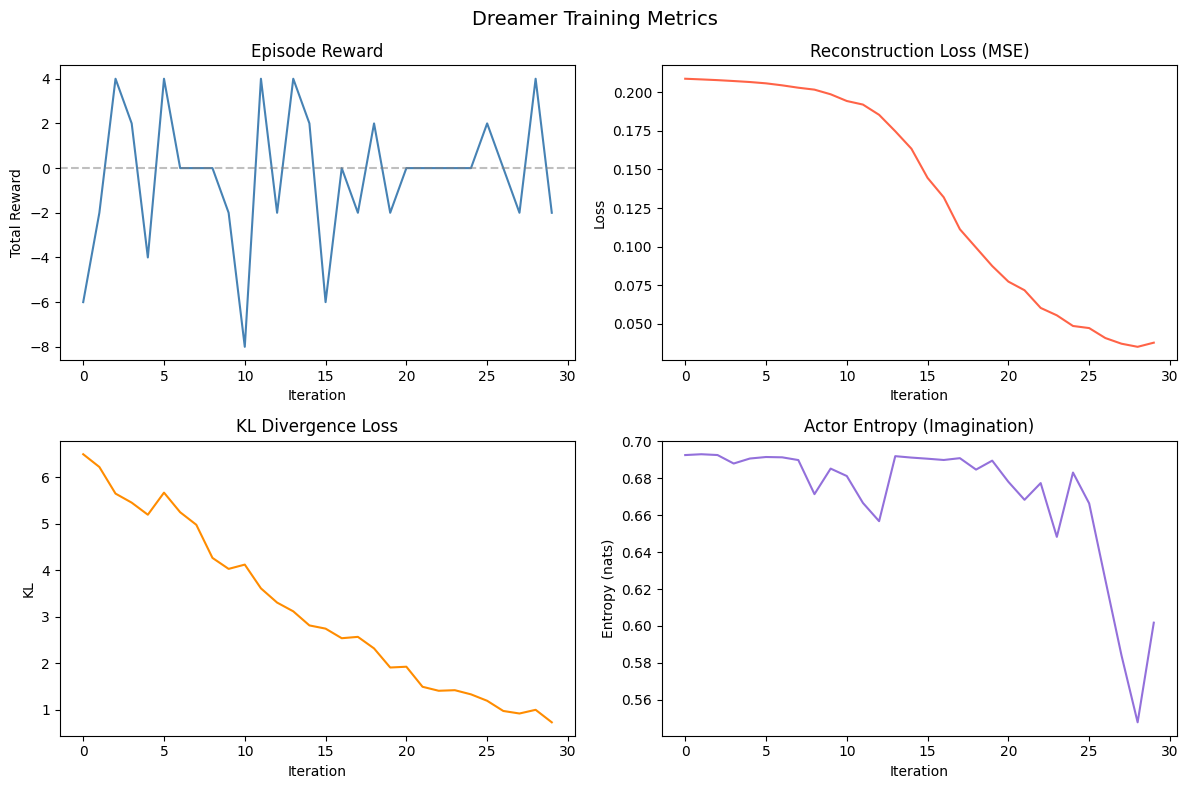

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Dreamer Training Metrics', fontsize=14)

axes[0, 0].plot(ep_rewards, color='steelblue')
axes[0, 0].set_title('Episode Reward')
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('Total Reward')
axes[0, 0].axhline(0, color='gray', linestyle='--', alpha=0.5)

axes[0, 1].plot(recon_losses, color='tomato')
axes[0, 1].set_title('Reconstruction Loss (MSE)')
axes[0, 1].set_xlabel('Iteration')
axes[0, 1].set_ylabel('Loss')

axes[1, 0].plot(kl_losses, color='darkorange')
axes[1, 0].set_title('KL Divergence Loss')
axes[1, 0].set_xlabel('Iteration')
axes[1, 0].set_ylabel('KL')

axes[1, 1].plot(actor_entropies, color='mediumpurple')
axes[1, 1].set_title('Actor Entropy (Imagination)')
axes[1, 1].set_xlabel('Iteration')
axes[1, 1].set_ylabel('Entropy (nats)')

plt.tight_layout()
plt.show()

## 5. 자체 평가 지표

이 절은 [L04의 Dreamer 예제](../lectures/lecture-04-evaluation-by-model/01-model-metrics-dreamer#reward-correlation)에서 나온 진단을 그대로 구현합니다. 같은 시작 상태에 대해 월드모델이 *상상하는* 보상과 실제 환경이 *실제로 반환하는* 보상을 비교합니다. `imagined_rollout_rewards`는 `imagined_rollout`(3절)의 읽기 전용 변형으로, 각 상상 스텝에서 액터의 엔트로피도 함께 추적합니다. 강의의 진단 규칙이 정상적인 Dreamer를 판단할 때 보상 상관관계뿐 아니라 엔트로피도 함께 확인하도록 요구하기 때문입니다.

In [15]:
def imagined_rollout_rewards(start_h, start_z, horizon=10, deterministic=True):
    """Roll forward in imagination using the Actor and reward model."""
    actor.eval()
    reward_model.eval()
    rssm.eval()
    h, z = start_h.clone(), start_z.clone()
    im_rewards = []
    im_entropies = []

    with torch.no_grad():
        for _ in range(horizon):
            logits = actor(h, z)
            dist   = torch.distributions.Categorical(logits=logits)
            im_entropies.append(dist.entropy().mean().item())
            if deterministic:
                a = torch.argmax(logits, dim=-1)
            else:
                a = dist.sample()
            a_oh   = F.one_hot(a, num_classes=ACTION_DIM).float()
            r_hat  = reward_model(h, z, a_oh).mean().item()
            im_rewards.append(r_hat)
            h = rssm.step(h, z, a_oh)
            prior_out = rssm.prior_net(h)
            z, _ = prior_out.chunk(2, dim=-1)

    return im_rewards, im_entropies


N_EVAL     = 10
EVAL_H     = EPISODE_LEN

real_reward_sums  = []
imag_reward_sums  = []
imag_entropies_ev = []

encoder.eval()
rssm.eval()
actor.eval()
reward_model.eval()

for ep_i in range(N_EVAL):
    # Collect real episode
    traj, ep_r = collect_episode(env_seed=1000 + ep_i, deterministic=True)
    real_reward_sums.append(sum(traj['rewards']))

    # Get RSSM state from first step as imagination seed
    h0, z0 = get_rssm_states_from_traj(traj)
    seed_h  = h0[0:1]   # single step
    seed_z  = z0[0:1]

    # Imagined rewards and entropy
    im_r, ents = imagined_rollout_rewards(seed_h, seed_z, horizon=EVAL_H, deterministic=True)
    imag_reward_sums.append(sum(im_r))
    imag_entropies_ev.append(float(np.mean(ents)))

print(f'Eval over {N_EVAL} episodes complete.')
print(f'  Mean real reward (full episode):          {np.mean(real_reward_sums):.3f}')
print(f'  Mean imagined reward (predicted):         {np.mean(imag_reward_sums):.3f}')
print(f'  Mean imagined trajectory entropy:         {np.mean(imag_entropies_ev):.4f}')


Eval over 10 episodes complete.
  Mean real reward (full episode):          -8.800
  Mean imagined reward (predicted):         -0.200
  Mean imagined trajectory entropy:         0.6134


상상 헬퍼를 정의했으니, 상상된 보상과 실제 반환값을 비교해 계획이 환경과 일치하는지 확인합니다. `N_EVAL = 10`개의 새 에피소드가 `deterministic=True`(항상 액터의 최고 로짓 동작을 선택하고 탐험 노이즈 없음)로 수집되고, 각 에피소드에 대해 첫 실제 관측 이후의 RSSM 사후분포 상태가 같은 길이의 상상된 롤아웃의 시작점이 됩니다. 같은 시작 상태에 대해 `real_reward_sums`와 `imag_reward_sums`를 비교하는 것이 바로 강의가 권장하는 "같은 초기 상태에서 시작하는" 비교입니다. 둘이 서로를 따라간다면 월드모델의 보상 예측은 계획에 믿고 쓸 수 있는 입력이고, 둘이 벌어진다면 상상된 보상은 동작 선택을 이끌기에 신뢰할 수 없다는 뜻이며, 이는 [Actor-Critic 계획 강의](../lectures/lecture-03-architecture-patterns/05-planning-cem-ac#mechanism-2-actor-critic-in-latent-space-dreamers-approach)에서 설명한 모델 착취(model exploitation) 위험입니다.

In [16]:
# Pearson correlation between imagined and real reward sums
r_real = np.array(real_reward_sums)
r_imag = np.array(imag_reward_sums)

if r_real.std() > 1e-8 and r_imag.std() > 1e-8:
    rho = np.corrcoef(r_real, r_imag)[0, 1]
else:
    rho = 0.0

print(f'Reward correlation rho (predicted vs real, {EVAL_H}-step): {rho:.4f}')
print(f'Mean imagined trajectory entropy:                          {np.mean(imag_entropies_ev):.4f}')


Reward correlation rho (predicted vs real, 20-step): -0.2341
Mean imagined trajectory entropy:                          0.6134


요약 지표를 마련했으니, 빠른 검증을 위해 진단 그래프들을 나란히 배치합니다. 이전 셀에서 `np.corrcoef`로 계산한 `rho`는 [L04](../lectures/lecture-04-evaluation-by-model/01-model-metrics-dreamer#reward-correlation)의 피어슨 상관계수 $\rho = \text{Pearson}(r_{\text{imagined}}, r_{\text{real}})$ 그 자체이며, 강의는 정상적인 월드모델의 목표로 `ρ ≥ 0.8`을 권장합니다. 30번의 반복만 학습한 이 작은 튜토리얼 규모 에이전트에서는 그 실전 배포 목표보다 더 들쭉날쭉한 값이 나올 것으로 예상하세요. 산점도의 대각 점선은 완벽한 일치(`imagined = real`)를 나타냅니다. 그 선에서 멀리 흩어진 점들, 특히 체계적으로 선 위쪽에 있는 점들은 강의가 경고하는 월드모델의 "거짓말"을 보여주는 시각적 신호입니다.

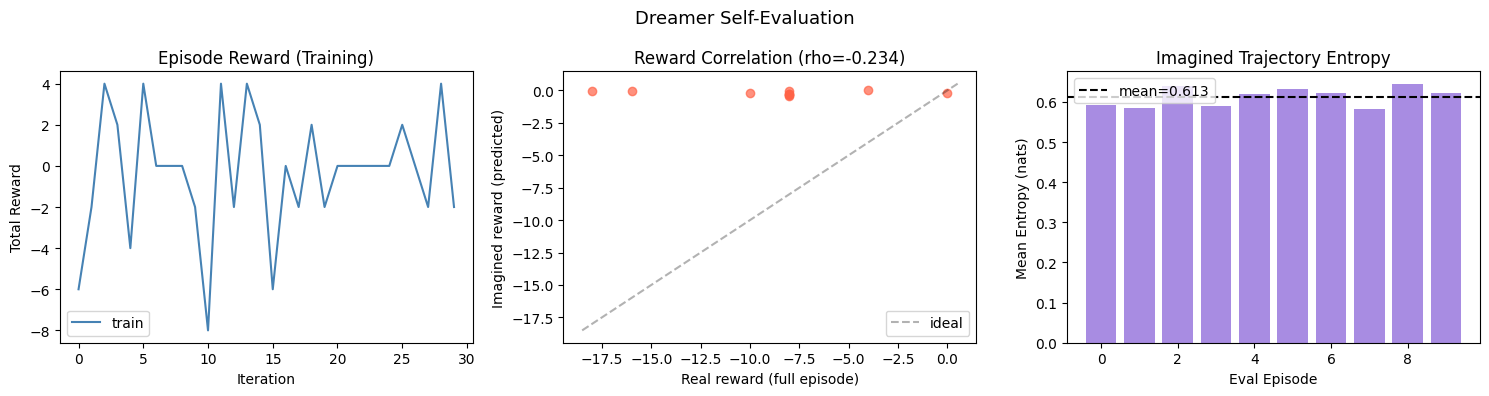

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Dreamer Self-Evaluation', fontsize=13)

# Episode reward over training
axes[0].plot(ep_rewards, color='steelblue', label='train')
axes[0].set_title('Episode Reward (Training)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Total Reward')
axes[0].legend()

# Reward correlation scatter
axes[1].scatter(r_real, r_imag, color='tomato', alpha=0.7)
axes[1].set_title(f'Reward Correlation (rho={rho:.3f})')
axes[1].set_xlabel(f'Real reward (full episode)')
axes[1].set_ylabel('Imagined reward (predicted)')
lims = [min(r_real.min(), r_imag.min()) - 0.5, max(r_real.max(), r_imag.max()) + 0.5]
axes[1].plot(lims, lims, 'k--', alpha=0.3, label='ideal')
axes[1].legend()

# Imagined trajectory entropy per eval episode
axes[2].bar(range(N_EVAL), imag_entropies_ev, color='mediumpurple', alpha=0.8)
axes[2].set_title('Imagined Trajectory Entropy')
axes[2].set_xlabel('Eval Episode')
axes[2].set_ylabel('Mean Entropy (nats)')
axes[2].axhline(np.mean(imag_entropies_ev), color='black', linestyle='--', label=f'mean={np.mean(imag_entropies_ev):.3f}')
axes[2].legend()

plt.tight_layout()
plt.show()


## 6. 체크포인트 저장

P02와 달리 RSSM만이 아니라 학습된 모든 구성 요소(`encoder`, `decoder`, `rssm`, `actor`, `critic`, `reward_model`)와 전체 지표 이력을 저장합니다. P05의 평가 대시보드가 5절의 보상 상관관계와 엔트로피 진단을 필요할 때 재현하려면 동역학 핵심만이 아니라 완전한 에이전트가 필요하기 때문입니다.

In [18]:
checkpoint = {
    'encoder': encoder.state_dict(),
    'decoder': decoder.state_dict(),
    'rssm':    rssm.state_dict(),
    'actor':   actor.state_dict(),
    'critic':  critic.state_dict(),
    'reward_model': reward_model.state_dict(),
    'hyperparams': {
        'latent_dim':  LATENT_DIM,
        'hidden_dim':  HIDDEN_DIM,
        'action_dim':  ACTION_DIM,
        'ac_hidden':   AC_HIDDEN,
    },
    'metrics': {
        'ep_rewards':      ep_rewards,
        'recon_losses':    recon_losses,
        'kl_losses':       kl_losses,
        'reward_losses':   reward_losses,
        'policy_losses':   policy_losses,
        'actor_entropies': actor_entropies,
        'reward_corr_rho': float(rho),
        'mean_imag_entropy': float(np.mean(imag_entropies_ev)),
        'mean_eval_reward': float(np.mean(real_reward_sums)),
        'mean_pred_reward': float(np.mean(imag_reward_sums)),
    },
}
torch.save(checkpoint, SAVE_PATH)
print(f'Checkpoint saved to {SAVE_PATH}')

# Summary
print('\n--- Training Summary ---')
print(f'  Final exploratory episode reward (last 10 avg): {np.mean(ep_rewards[-10:]):.2f}')
print(f'  Final reconstruction loss:          {recon_losses[-1]:.4f}')
print(f'  Final KL loss:                      {kl_losses[-1]:.4f}')
print(f'  Final reward loss:                  {reward_losses[-1]:.4f}')
print(f'  Final policy loss:                  {policy_losses[-1]:.4f}')
print(f'  Final actor entropy:                {actor_entropies[-1]:.4f}')
print(f'  Reward correlation rho:             {rho:.4f}')
print(f'  Mean imagined trajectory entropy:   {np.mean(imag_entropies_ev):.4f}')
print(f'  Mean eval reward:                   {np.mean(real_reward_sums):.2f}')


Checkpoint saved to dreamer.pt

--- Training Summary ---
  Final exploratory episode reward (last 10 avg): 0.20
  Final reconstruction loss:          0.0379
  Final KL loss:                      0.7316
  Final reward loss:                  1.0053
  Final policy loss:                  0.5993
  Final actor entropy:                0.6018
  Reward correlation rho:             -0.2341
  Mean imagined trajectory entropy:   0.6134
  Mean eval reward:                   -8.80
